# 3D map analysis of RX J1713.7−3946

This notebook introduces a three-dimensional gamma-ray analysis workflow with Gammapy using public H.E.S.S. DL3 observations of the shell-type supernova remnant RX J1713.7−3946.

The goal is to build a 3D `MapDataset`, fit spatial and spectral source models, and inspect diagnostics such as excess and residual maps. We first use a Gaussian morphology as a simple extended-source model, then compare it with a shell morphology motivated by the known structure of RX J1713.7−3946. We also illustrate a simple nested amplitude test using `select_nested_models()`.

## Workflow

1. Load the public H.E.S.S. DL3 DR1 observations.
2. Select observations targeting RX J1713.7−3946.
3. Define a 3D WCS geometry with spatial and energy axes.
4. Build one `MapDataset` per observation and stack them.
5. Fit an extended Gaussian source model with a power-law spectrum.
6. Inspect excess and residual maps.
7. Use `select_nested_models()` for a simple nested amplitude test.
8. Compare Gaussian and Shell spatial morphologies as alternative descriptions of the source.

## Requirements

This notebook was prepared with Gammapy v1.3 and requires the public Gammapy datasets. The environment variable `GAMMAPY_DATA` should point to a directory containing `hess-dl3-dr1`.

In [1]:
import logging
import warnings

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import Angle, SkyCoord
from regions import CircleSkyRegion

from gammapy.data import DataStore
from gammapy.datasets import Datasets, MapDataset
from gammapy.estimators import ExcessMapEstimator
from gammapy.makers import FoVBackgroundMaker, MapDatasetMaker, SafeMaskMaker
from gammapy.maps import MapAxis, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    FoVBackgroundModel,
    GaussianSpatialModel,
    Models,
    PointSpatialModel,
    PowerLawSpectralModel,
    ShellSpatialModel,
    SkyModel,
)
from gammapy.modeling.selection import select_nested_models


logging.basicConfig()
log = logging.getLogger("rxj1713-3d-hess")
log.setLevel(logging.INFO)

## Loading H.E.S.S. DL3 observations

We start by loading the public H.E.S.S. DL3 DR1 dataset distributed with the Gammapy datasets.

DL3 data contain event lists and instrument response functions for individual observations. In a 3D analysis, we use these observations to build counts, exposure, PSF, energy-dispersion, and background maps on a common spatial and energy geometry.

In [2]:
# Load the public H.E.S.S. DL3 DR1 data
data_store = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1")

print(f"Number of observations in the data store: {len(data_store.obs_table)}")
data_store.obs_table[:5]

Number of observations in the data store: 105


OBS_ID,RA_PNT,DEC_PNT,GLON_PNT,GLAT_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,OBJECT,RA_OBJ,DEC_OBJ,OFFSET_OBJ,ONTIME,LIVETIME,DEADC,TSTART,TSTOP,DATE-OBS,TIME-OBS,DATE-END,TIME-END,N_TELS,TELLIST,QUALITY,MUONEFF,EVENT_COUNT,TARGET_NAME,TARGET_TAG,TARGET_OFFSET,SAFE_ENERGY_LO,SAFE_ENERGY_HI
,deg,deg,deg,deg,deg,deg,deg,,deg,deg,deg,s,s,,s,s,,,,,,,,,,,,deg,TeV,TeV
int64,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float64,float64,bytes10,bytes12,bytes10,bytes12,int64,bytes7,int64,float32,int64,bytes21,bytes14,float32,float32,float32
20136,228.6125,-58.771667,320.56754,-0.8857012,38.512962,51.487038,195.73102,MSH15-52,228.6125,-59.271667,0.5,1682.0,1521.0269,0.9042966,101962602.0,101964284.0,2004-03-26,02:57:46.184,2004-03-26,03:25:48.184,4,"1,2,3,4",0,1.2132596,11243,MSH 15-52,msh1552,0.38821736,0.40738028,100.0
20137,228.6125,-59.771667,320.04724,-1.7397733,40.21616,49.78384,199.6482,MSH15-52,228.6125,-59.271667,0.5,902.0,819.2054,0.90821,101964441.0,101965343.0,2004-03-26,03:28:25.184,2004-03-26,03:43:27.184,4,"1,2,3,4",0,1.2139559,5693,MSH 15-52,msh1552,0.6156251,0.40738028,100.0
20151,228.6125,-58.771667,320.56754,-0.8857012,37.164658,52.835342,190.97171,custom,228.6125,-59.271667,0.5,1683.0,1530.479,0.9093755,102047232.0,102048915.0,2004-03-27,02:28:16.184,2004-03-27,02:56:19.184,4,"1,2,3,4",0,1.2214733,10722,MSH 15-52,msh1552,0.38821736,0.40738028,100.0
20275,187.27792,2.552389,289.7155,64.849686,36.18243,53.81757,49.144917,3C 273,187.27792,2.052389,0.5,1683.0,1525.8447,0.90662193,103665036.0,103666719.0,2004-04-14,19:51:40.184,2004-04-14,20:19:43.184,4,"1,2,3,4",0,1.121256,10646,Off data,offdata,--,0.33113113,100.0
20282,228.6125,-58.771667,320.56754,-0.8857012,37.13134,52.86866,169.21602,MSH 15-5-02,228.6125,-59.271667,0.5,1687.0,1543.3231,0.9148329,103678269.0,103679956.0,2004-04-14,23:32:13.184,2004-04-15,00:00:20.184,4,"1,2,3,4",0,1.1495326,11063,MSH 15-52,msh1552,0.38821736,0.40738028,100.0


## Defining the target position

RX J1713.7−3946 is an extended supernova remnant located close to the Galactic plane. For this analysis, we work in Galactic coordinates and define the target position near $(l, b) \simeq (347.34^\circ, -0.47^\circ)$.

In [3]:
target_position = SkyCoord(
    l=347.34 * u.deg,
    b=-0.47 * u.deg,
    frame="galactic",
)

target_position

<SkyCoord (Galactic): (l, b) in deg
    (347.34, -0.47)>

## Selecting observations by sky position

We select observations whose pointing positions lie within a 5 deg radius around RX J1713.7−3946.

This relatively large selection radius is useful for retrieving the relevant H.E.S.S. DR1 observations, including wobble pointings where the source is offset from the camera center. The selection radius is only used to retrieve observations from the `DataStore`; it does not define the final map geometry used for the 3D analysis.

In [4]:
selection = {
    "type": "sky_circle",
    "frame": "galactic",
    "lon": 347.34 * u.deg,
    "lat": -0.47 * u.deg,
    "radius": 5 * u.deg,  # Selection radius for retrieving relevant observations
}

selected_obs_table = data_store.obs_table.select_observations(selection)

## Inspecting the selected observation table

Before loading the observations, we inspect the selected observation table. This table contains useful metadata such as pointing position, zenith angle, livetime, and target name.

This is a basic sanity check to confirm that the selected observations correspond to the intended target field.

In [5]:
selected_obs_table

OBS_ID,RA_PNT,DEC_PNT,GLON_PNT,GLAT_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,OBJECT,RA_OBJ,DEC_OBJ,OFFSET_OBJ,ONTIME,LIVETIME,DEADC,TSTART,TSTOP,DATE-OBS,TIME-OBS,DATE-END,TIME-END,N_TELS,TELLIST,QUALITY,MUONEFF,EVENT_COUNT,TARGET_NAME,TARGET_TAG,TARGET_OFFSET,SAFE_ENERGY_LO,SAFE_ENERGY_HI
,deg,deg,deg,deg,deg,deg,deg,,deg,deg,deg,s,s,,s,s,,,,,,,,,,,,deg,TeV,TeV
int64,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float64,float64,bytes10,bytes12,bytes10,bytes12,int64,bytes7,int64,float32,int64,bytes21,bytes14,float32,float32,float32
20326,259.29852,-39.762222,347.74036,-1.0417831,18.712194,71.2878,154.81943,RXJ 1713.7-3946,258.3879,-39.762222,0.6999909,1683.0,1500.009,0.891271,103858277.0,103859960.0,2004-04-17,01:32:21.184,2004-04-17,02:00:24.184,4,"1,2,3,4",0,1.1412385,16880,RX J1713.7-3946,rxj1713,0.7252947,0.23442288,100.0
20327,257.47733,-39.762222,346.91946,0.092252225,16.734882,73.265114,173.0282,RXJ 1713.7-3946,258.3879,-39.762222,0.69996744,1683.0,1497.074,0.889527,103860109.0,103861792.0,2004-04-17,02:02:53.184,2004-04-17,02:30:56.184,4,"1,2,3,4",0,1.1392112,16995,RX J1713.7-3946,rxj1713,0.6746846,0.20417379,100.0
20349,259.29852,-39.762222,347.74036,-1.0417831,16.722466,73.277534,186.67764,RXJ 1713.7-3946,258.3879,-39.762222,0.6999909,1682.0,1494.5023,0.888527,103947504.0,103949186.0,2004-04-18,02:19:28.184,2004-04-18,02:47:30.184,4,"1,2,3,4",0,1.1592567,16141,RX J1713.7-3946,rxj1713,0.7252947,0.20417379,100.0
20350,257.47733,-39.762222,346.91946,0.092252225,18.658506,71.34149,204.89865,RXJ 1713.7-3946,258.3879,-39.762222,0.69996744,1682.0,1497.6545,0.890401,103949330.0,103951012.0,2004-04-18,02:49:54.184,2004-04-18,03:17:56.184,4,"1,2,3,4",0,1.1565586,16081,RX J1713.7-3946,rxj1713,0.6746846,0.23442288,100.0
20396,258.3879,-39.06222,347.8998,-0.062237248,16.931627,73.068375,190.61954,RXJ 1713.7-3946,258.3879,-39.762222,0.70000076,1683.0,1499.001,0.89067197,104120195.0,104121878.0,2004-04-20,02:17:39.184,2004-04-20,02:45:42.184,4,"1,2,3,4",0,1.1642822,16418,RX J1713.7-3946,rxj1713,0.7092343,0.20417379,100.0
20397,258.3879,-40.462223,346.76566,-0.8830993,19.253716,70.746284,207.88188,RXJ 1713.7-3946,258.3879,-39.762222,0.70000076,1682.0,1505.1713,0.89487,104122008.0,104123690.0,2004-04-20,02:47:52.184,2004-04-20,03:15:54.184,4,"1,2,3,4",0,1.1711123,15798,RX J1713.7-3946,rxj1713,0.691681,0.23442288,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20518,258.3879,-39.06222,347.8998,-0.062237248,16.80531,73.194695,171.5077,RXJ 1713.7-3946,258.3879,-39.762222,0.70000076,1682.0,1506.199,0.895481,104463121.0,104464803.0,2004-04-24,01:33:05.184,2004-04-24,02:01:07.184,4,"1,2,3,4",0,1.1684012,14636,RX J1713.7-3946,rxj1713,0.7092343,0.20417379,100.0


## Building the observation list

The selection above returns rows from the observation table. We now use the selected `OBS_ID` values to load the corresponding `Observation` objects.

These objects provide access to the event lists and instrument response functions needed to build the 3D datasets.

In [6]:
obs_ids = selected_obs_table["OBS_ID"]
observations = data_store.get_observations(obs_ids)

print(f"Selected observation IDs: {list(obs_ids)}")
print(f"Number of selected observations: {len(observations)}")

INFO:gammapy.data.data_store:Observations selected: 15 out of 15.


Selected observation IDs: [20326, 20327, 20349, 20350, 20396, 20397, 20421, 20422, 20517, 20518, 20519, 20521, 20898, 20899, 20900]
Number of selected observations: 15


## Inspecting one representative observation

Before building the 3D datasets, we inspect one observation in more detail.

In [7]:
obs_0 = observations[0]

print(obs_0)

Observation

	obs id            : 20326 
 	tstart            : 53112.06
	tstop             : 53112.08
	duration          : 1683.00 s
	pointing (icrs)   : 259.3 deg, -39.8 deg

	deadtime fraction : 10.9%



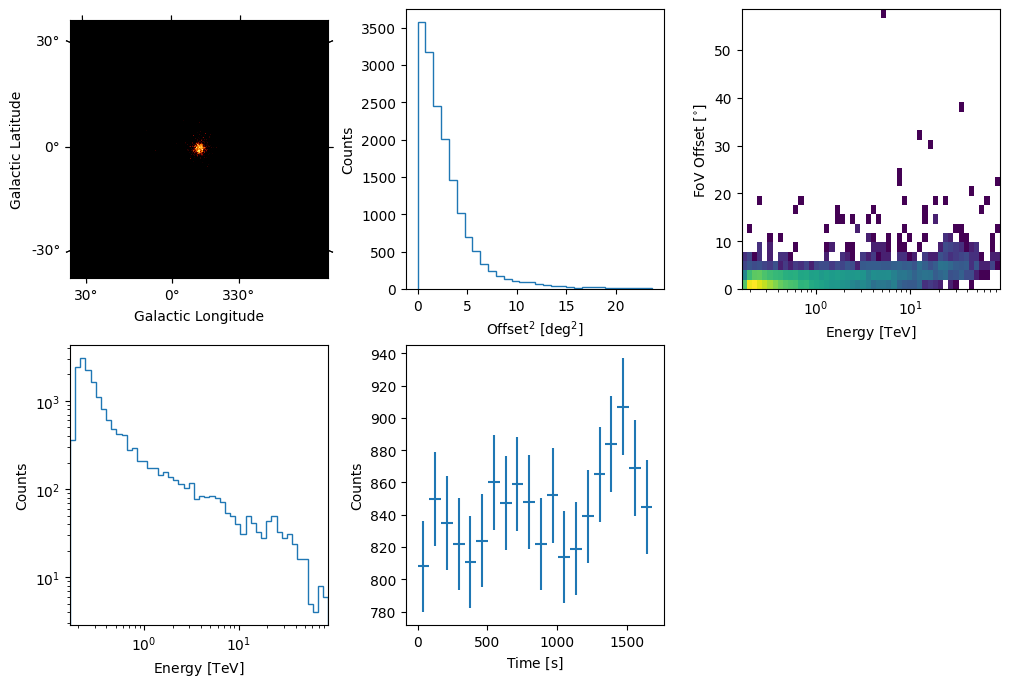

In [8]:
# Quick-look diagnostic plot for the event list
obs_0.events.peek()

## Inspect IRFs

Each observation comes with IRFs: effective area (AEFF), energy dispersion (EDISP), and PSF.

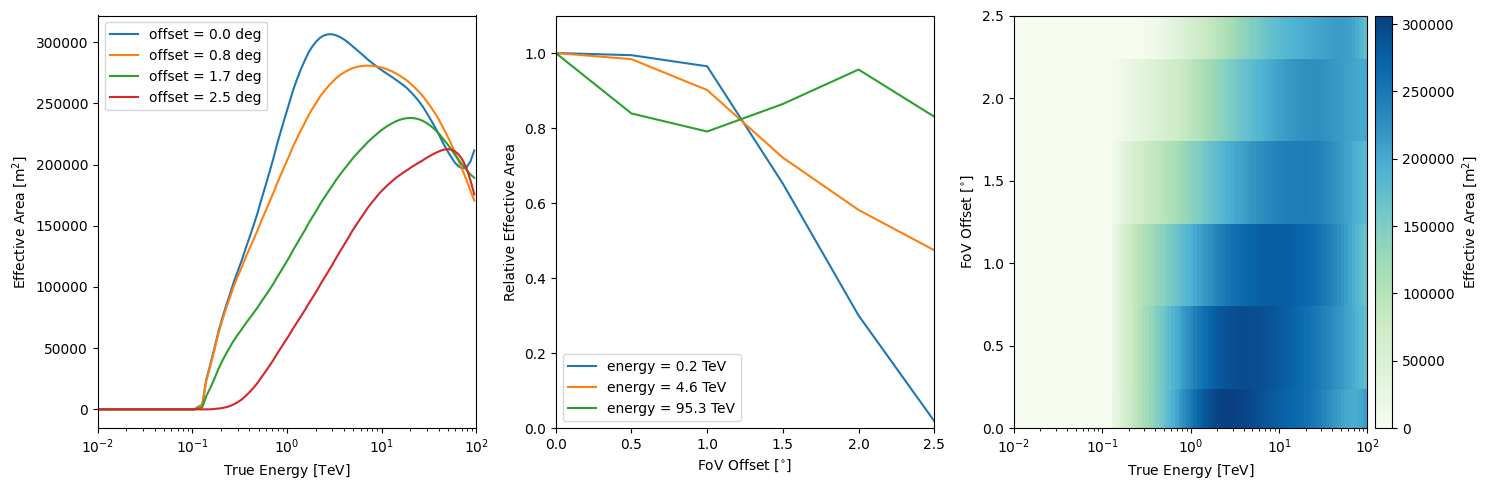

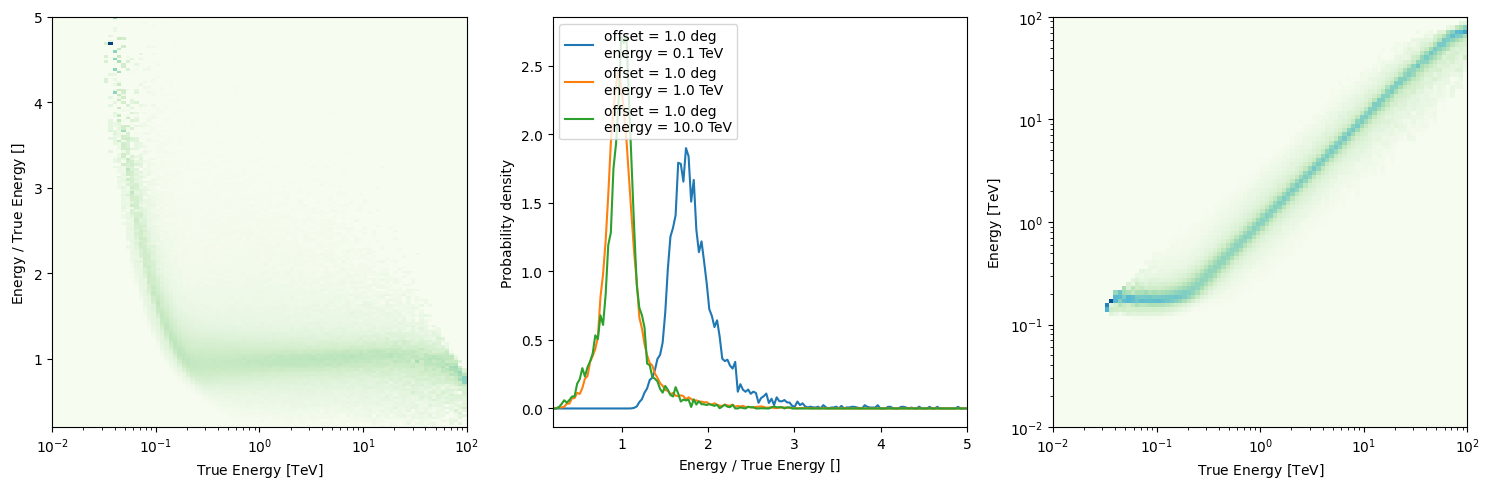

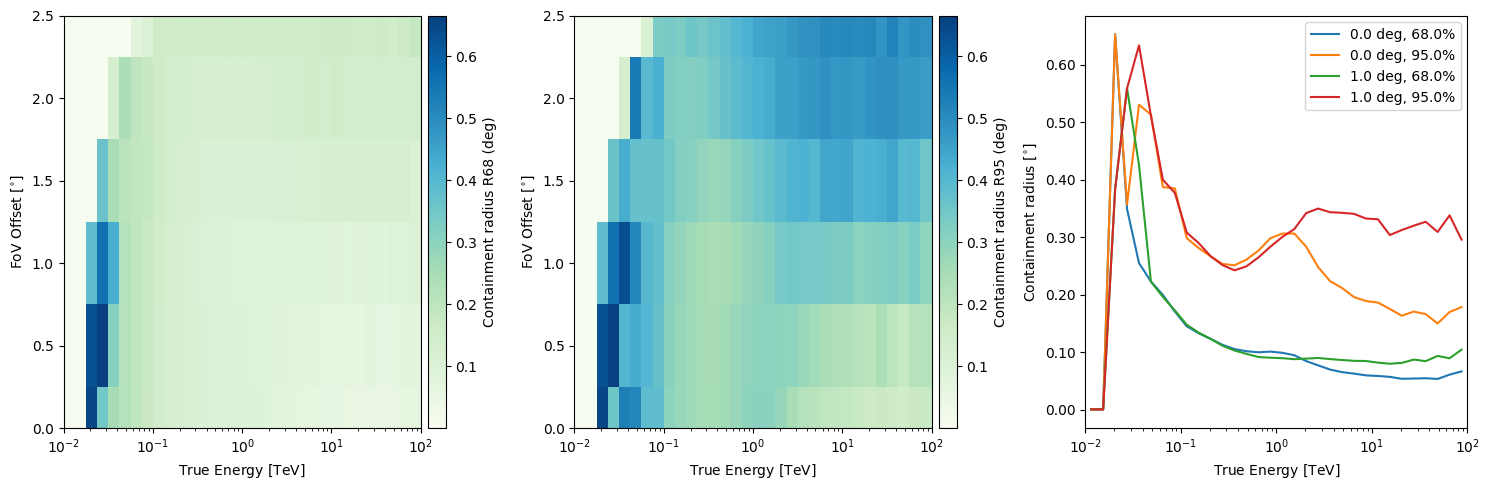

In [9]:
# Inspect the effective area, energy dispersion, and PSF
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message="invalid value encountered in divide",
        category=RuntimeWarning,
    )

    obs_0.aeff.peek()
    obs_0.edisp.peek()
    obs_0.psf.peek()

## Inspect Background model

Check the field-of-view background model provided with the observation.


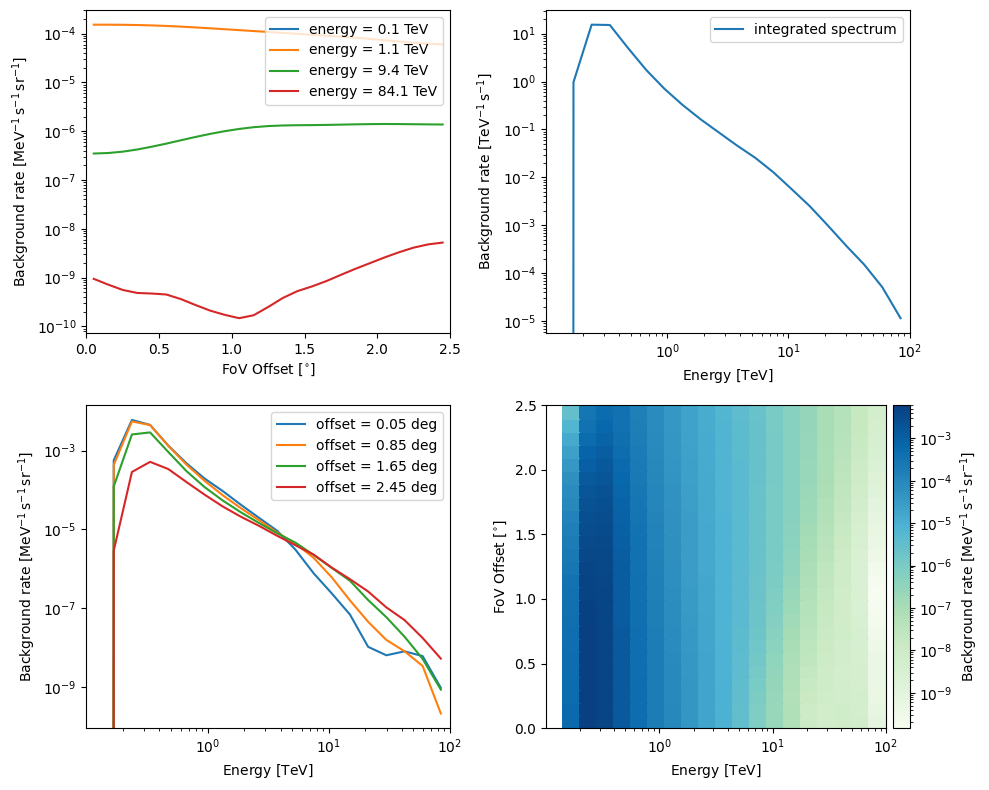

In [10]:
obs_0.bkg.peek()

## Preparing the 3D dataset geometry

We now define the reference geometry for the 3D analysis.

The geometry specifies the spatial grid and the reconstructed-energy axis used for the counts map and model evaluation. In this example, we use a WCS geometry centered on RX J1713.7−3946, with a pixel size of `0.02 deg` and a field of view of `6 deg × 6 deg`.

We also define a true-energy axis, which is used internally to evaluate the instrument response functions, such as exposure, PSF, and energy dispersion. The true-energy axis is usually wider and more finely binned than the reconstructed-energy axis.

In [11]:
# Reconstructed-energy axis: used for the counts cube
energy_axis = MapAxis.from_energy_bounds(
    0.3,
    10.0,
    15,
    unit="TeV",
    name="energy",
)

# Spatial + reconstructed-energy geometry
geom = WcsGeom.create(
    skydir=target_position,
    binsz=0.02,
    width=(6, 6),
    frame="galactic",
    axes=[energy_axis],
)

# True-energy axis: used internally for IRF evaluation and model prediction
energy_axis_true = MapAxis.from_energy_bounds(
    0.1,
    20.0,
    20,
    unit="TeV",
    name="energy_true",
)

In [12]:
# Inspect the analysis geometry
geom

## Data reduction with the FoV background method

We now reduce the selected DL3 observations into 3D `MapDataset` objects.

For this tutorial, we use the field-of-view (FoV) background method. In this approach, a background model is estimated from the data using the field of view, while excluding regions associated with gamma-ray emission.

We start by creating an empty stacked dataset, which will be used as an accumulator when looping over the selected observations.

In [13]:
# Create an empty stacked dataset
stacked = MapDataset.create(
    geom=geom,
    energy_axis_true=energy_axis_true,
    name="rxj-stacked",
)

stacked

## Exclusion mask

For the FoV background method, regions containing gamma-ray emission should be excluded from the background estimation.

RX J1713.7−3946 is an extended source, so we define a circular exclusion region around the remnant. Here we use a radius of **0.7 deg** centered on the target position. This value is chosen as a simple tutorial example and can be adjusted depending on the source morphology and analysis region.

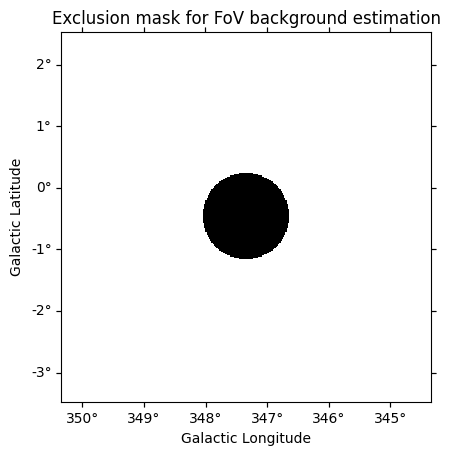

In [14]:
# Define the exclusion region around RX J1713.7-3946
exclusion_region = CircleSkyRegion(
    center=target_position,
    radius=0.7 * u.deg,
)

# Build the exclusion mask on the full 3D geometry
exclusion_mask = ~geom.region_mask(regions=[exclusion_region])

# Build a 2D version only for visualization
exclusion_mask_2d = ~geom.to_image().region_mask(regions=[exclusion_region])

ax = exclusion_mask_2d.plot(add_cbar=False)
ax.set_title("Exclusion mask for FoV background estimation");

## Creating the makers

We now define the maker objects that perform the data reduction for each observation.

- `MapDatasetMaker` fills the counts, exposure, PSF, energy dispersion, and background maps.
- `SafeMaskMaker` defines the safe data range for each observation.
- `FoVBackgroundMaker` fits the field-of-view background normalization while excluding the source region defined above.

The FoV background normalization is fitted separately for each observation before stacking the datasets.

In [15]:
# Create the dataset maker
maker = MapDatasetMaker(
    selection=["counts", "background", "psf", "edisp", "exposure"],
)

# Define the safe data range for each observation
safe_mask_maker = SafeMaskMaker(
    methods=["offset-max", "aeff-max", "bkg-peak"],
    offset_max="2.3 deg",
)

# Fit the FoV background normalization outside the exclusion region
fov_bkg_maker = FoVBackgroundMaker(
    method="fit",
    exclusion_mask=exclusion_mask,
)

## Running the data reduction and stacking

We now loop over the selected observations and build one `MapDataset` per observation.

For each observation, we:

1. fill the counts, exposure, PSF, energy dispersion, and background maps;
2. apply the safe data mask;
3. fit the FoV background normalization outside the exclusion region;
4. stack the reduced dataset into the `stacked` dataset.

The fitted FoV background normalization is printed for each observation as a useful sanity check.

In [16]:
for obs in observations:
    dataset = MapDataset.create(
        geom=geom,
        energy_axis_true=energy_axis_true,
        name=f"obs-{obs.obs_id}",
    )

    dataset = maker.run(dataset, obs)
    dataset = safe_mask_maker.run(dataset, obs)
    dataset = fov_bkg_maker.run(dataset)

    background_norm = dataset.background_model.spectral_model.norm.value
    print(f"Background norm - OBS_ID {obs.obs_id}: {background_norm:.2f}")

    stacked.stack(dataset)

stacked

Background norm - OBS_ID 20326: 1.04
Background norm - OBS_ID 20327: 1.06
Background norm - OBS_ID 20349: 1.01
Background norm - OBS_ID 20350: 1.05
Background norm - OBS_ID 20396: 1.01
Background norm - OBS_ID 20397: 1.08
Background norm - OBS_ID 20421: 1.08
Background norm - OBS_ID 20422: 1.01
Background norm - OBS_ID 20517: 1.01
Background norm - OBS_ID 20518: 0.97
Background norm - OBS_ID 20519: 1.00
Background norm - OBS_ID 20521: 1.03
Background norm - OBS_ID 20898: 1.13
Background norm - OBS_ID 20899: 1.04
Background norm - OBS_ID 20900: 1.00


The fitted FoV background normalizations are close to unity for most observations. This indicates that the initial background model provides a reasonable description of the data outside the exclusion region, requiring only small normalization adjustments before stacking.

The stacked dataset now contains the combined counts, exposure, PSF, energy dispersion, background model, and safe mask for the selected observations.

Optionally, the stacked dataset can be written to disk for later use:

```python
stacked.write("stacked_MapDataset.fits", overwrite=True)

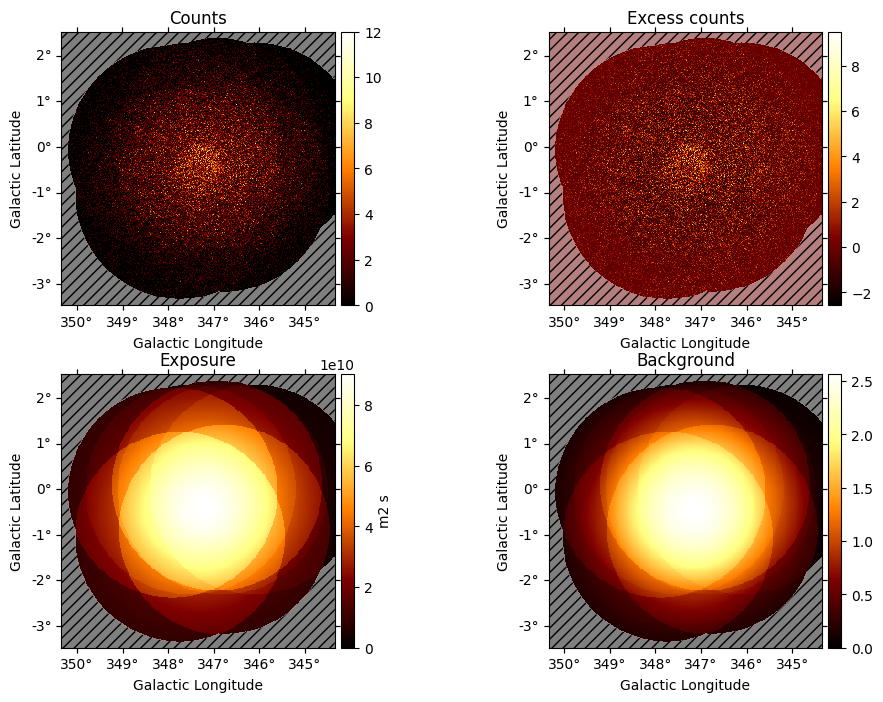

In [17]:
stacked.write('stacked_MapDataset.fits',overwrite=True)
stacked.peek()

## Excess and significance maps before source modeling

Before fitting a source model, we can inspect where the data show an excess above the estimated FoV background.

We compute:

- an **excess map**, defined as counts minus background;
- a **significance-like map**, represented by `sqrt_ts`, which highlights regions where the excess is most significant.

For this diagnostic, we use a correlation radius of `0.1 deg` and integrate the maps between `0.4 TeV` and `20 TeV`. These choices provide a compact visual summary of the emission region before introducing a parametric source model.

In [18]:
# Estimate excess and sqrt(TS) maps in a broad energy band
excess_estimator = ExcessMapEstimator(
    correlation_radius="0.1 deg",
    energy_edges=[0.4, 20] * u.TeV,
)

excess_result = excess_estimator.run(stacked)

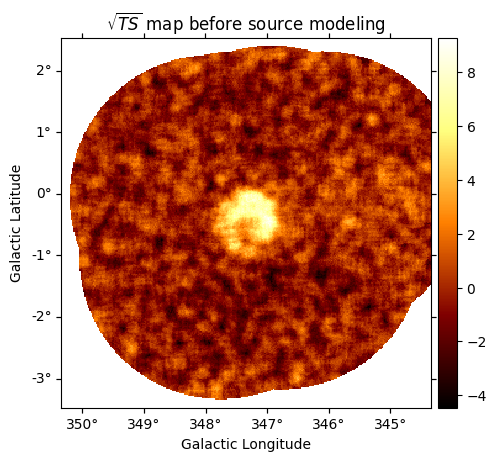

In [19]:
# Plot the sqrt(TS) map
ax = excess_result.sqrt_ts.plot(add_cbar=True)
ax.set_title(r"$\sqrt{TS}$ map before source modeling");

## 3D source modeling

We now define parametric models for the gamma-ray emission and fit them to the stacked 3D dataset.

Our source model combines:

- a **spatial model**, describing the morphology of the emission on the sky;
- a **spectral model**, describing the energy dependence of the flux.

We first model RX J1713.7−3946 with an extended Gaussian morphology and a power-law spectrum. This provides a simple baseline model for an extended source. Later, we compare this Gaussian morphology with a Shell model, which is more closely motivated by the known shell-like structure of the remnant.

### Gaussian extended source model

We start with a `GaussianSpatialModel` centered near the target position. The source position and extension are allowed to vary within reasonable bounds to keep the fit stable.

In [20]:
# Define a Gaussian spatial model for the source
gaussian_spatial_model = GaussianSpatialModel(
    lon_0=target_position.l,
    lat_0=target_position.b,
    sigma=0.3 * u.deg,
    frame="galactic",
)

# Restrict the fitted source center to a box around the initial position
gaussian_spatial_model.lon_0.min = gaussian_spatial_model.lon_0.value - 0.5
gaussian_spatial_model.lon_0.max = gaussian_spatial_model.lon_0.value + 0.5
gaussian_spatial_model.lat_0.min = gaussian_spatial_model.lat_0.value - 0.5
gaussian_spatial_model.lat_0.max = gaussian_spatial_model.lat_0.value + 0.5

gaussian_spatial_model

We now combine the Gaussian spatial morphology with a power-law spectral model. This defines the first complete source model for RX J1713.7−3946.

We also include a `FoVBackgroundModel` associated with the stacked dataset, so that the residual background normalization can be adjusted during the fit.


In [21]:
# Define a power-law spectral model for the source
gaussian_spectral_model = PowerLawSpectralModel(
    amplitude=1e-11 * u.Unit("cm-2 s-1 TeV-1"),
    index=2.0,
    reference=1 * u.TeV,
)

# Combine spatial and spectral components into a sky model
gaussian_source_model = SkyModel(
    spatial_model=gaussian_spatial_model,
    spectral_model=gaussian_spectral_model,
    name="rxj1713-gauss",
)

# Add a FoV background model for the stacked dataset
background_model = FoVBackgroundModel(dataset_name=stacked.name)

models_gauss = Models([gaussian_source_model, background_model])
stacked.models = models_gauss

models_gauss.to_parameters_table()

model,type,name,value,unit,error,min,max,frozen,link,prior
str15,str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
rxj1713-gauss,,index,2.0000e+00,,0.000e+00,nan,nan,False,,
rxj1713-gauss,,amplitude,1.0000e-11,cm-2 s-1 TeV-1,0.000e+00,nan,nan,False,,
rxj1713-gauss,,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
rxj1713-gauss,,lon_0,3.4734e+02,deg,0.000e+00,3.468e+02,3.478e+02,False,,
rxj1713-gauss,,lat_0,-4.7000e-01,deg,0.000e+00,-9.700e-01,3.000e-02,False,,
rxj1713-gauss,,sigma,3.0000e-01,deg,0.000e+00,0.000e+00,nan,False,,
rxj1713-gauss,,e,0.0000e+00,,0.000e+00,0.000e+00,1.000e+00,True,,
rxj1713-gauss,,phi,0.0000e+00,deg,0.000e+00,nan,nan,True,,
rxj-stacked-bkg,,norm,1.0000e+00,,0.000e+00,nan,nan,False,,


We now fit the Gaussian source model together with the FoV background model.


In [22]:
# Fit the Gaussian source model
fit = Fit()
fit_result_gauss = fit.run([stacked])

print(fit_result_gauss)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 226
	total stat : 406133.77

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [23]:
# Store the fit statistic for later model comparison
stat_gauss = fit_result_gauss.total_stat

print(f"Gaussian model fit statistic = {stat_gauss:.2f}")

Gaussian model fit statistic = 406133.77


In [24]:
# Inspect the fitted source parameters
gaussian_source_model.parameters.to_table()

type,name,value,unit,error,min,max,frozen,link,prior
str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
,index,1.9128e+00,,3.939e-02,nan,nan,False,,
,amplitude,2.3070e-11,cm-2 s-1 TeV-1,1.145e-12,nan,nan,False,,
,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
,lon_0,3.4726e+02,deg,1.751e-02,3.468e+02,3.478e+02,False,,
,lat_0,-3.7619e-01,deg,1.694e-02,-9.700e-01,3.000e-02,False,,
,sigma,3.6318e-01,deg,1.299e-02,0.000e+00,nan,False,,
,e,0.0000e+00,,0.000e+00,0.000e+00,1.000e+00,True,,
,phi,0.0000e+00,deg,0.000e+00,nan,nan,True,,


### Gaussian model diagnostics

After fitting the Gaussian model, we inspect residuals in both space and energy.

The spatial residual map shows where the model over- or under-predicts the data on the sky. The spectral residuals show how the agreement changes with energy. These plots are useful sanity checks before moving to more detailed model comparisons.

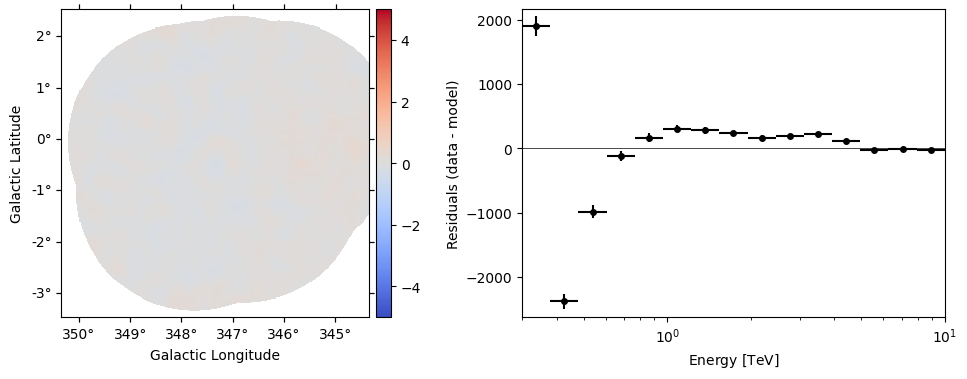

In [25]:
# Inspect spatial and spectral residuals for the Gaussian model
stacked.plot_residuals(
    kwargs_spatial=dict(method="diff/sqrt(model)", vmin=-5, vmax=5),
    kwargs_spectral=dict(method="diff"),
);

The spatial residual map is mostly close to zero after the Gaussian fit, indicating that the model captures the extended emission reasonably well in the sky map.

The spectral residuals show larger deviations in the lowest-energy bins. This can happen because the instrument response is worse close to the low-energy threshold, where the effective area, energy dispersion, and background modeling are more sensitive to analysis choices.

## Optional: nested amplitude test

As an example of a nested model comparison, we test whether the source component is required by the data.

The null hypothesis is obtained by fixing the source amplitude to zero. The alternative hypothesis allows the source amplitude to vary freely. This is a nested comparison because the no-source case is recovered from the same model by setting one parameter, the amplitude, to zero.

Here we use `select_nested_models()` to compute the corresponding test statistic.

In [26]:
# Save the current best-fit Gaussian model before running the nested test
models_gauss_best_fit = stacked.models.copy()

# Select the source amplitude as the parameter that defines the nested test
amplitude_parameter = gaussian_source_model.spectral_model.amplitude

# Null hypothesis: source amplitude fixed to zero
# Alternative hypothesis: source amplitude free
nested_results = select_nested_models(
    datasets=Datasets([stacked]),
    parameters=[amplitude_parameter],
    null_values=[0],
)

ts_amp = nested_results["ts"]
sigma_amp = np.sqrt(ts_amp)

print(f"TS_amp = {ts_amp:.2f}")
print(f"Detection significance = {sigma_amp:.2f} sigma")

TS_amp = 1068.60
Detection significance = 32.69 sigma


The nested amplitude test gives a very large value of $TS_{\rm amp}$, corresponding to an approximate significance well above the usual detection threshold.

This confirms that the source component is strongly required by the data, as expected. 

In [27]:
# Restore the best-fit Gaussian model before continuing
stacked.models = models_gauss_best_fit

## Comparing Gaussian and shell spatial morphologies

RX J1713.7−3946 is a shell-type supernova remnant, so a Shell morphology is physically motivated.

We now fit an alternative source model using `ShellSpatialModel`, combined with a power-law spectrum. The Gaussian and Shell morphologies are not nested in a simple way, so we compare their fit statistics only as a diagnostic model comparison, not as a nested likelihood-ratio test.

In [28]:
# Define a shell spatial model for RX J1713.7-3946
shell_spatial_model = ShellSpatialModel(
    lon_0=target_position.l,
    lat_0=target_position.b,
    radius=0.55 * u.deg,
    width=0.20 * u.deg,
    frame="galactic",
)

# Keep the source center fixed for a stable tutorial fit
shell_spatial_model.lon_0.frozen = True
shell_spatial_model.lat_0.frozen = True

# Keep shell parameters in a reasonable range
shell_spatial_model.radius.min = 0.2
shell_spatial_model.radius.max = 1.2
shell_spatial_model.width.min = 0.05
shell_spatial_model.width.max = 0.5

shell_spatial_model

We now combine the Shell morphology with a power-law spectrum and fit it to the same stacked dataset.

In [29]:
# Define a power-law spectral model for the shell morphology
shell_spectral_model = PowerLawSpectralModel(
    amplitude=gaussian_source_model.spectral_model.amplitude.quantity,
    index=gaussian_source_model.spectral_model.index.value,
    reference=1 * u.TeV,
)

shell_source_model = SkyModel(
    spatial_model=shell_spatial_model,
    spectral_model=shell_spectral_model,
    name="rxj1713-shell",
)

background_model_shell = FoVBackgroundModel(dataset_name=stacked.name)

models_shell = Models([shell_source_model, background_model_shell])
stacked.models = models_shell

models_shell.to_parameters_table()

model,type,name,value,unit,error,min,max,frozen,link,prior
str15,str1,str9,float64,str14,float64,float64,float64,bool,str1,str1
rxj1713-shell,,index,1.9127e+00,,0.000e+00,nan,nan,False,,
rxj1713-shell,,amplitude,2.3071e-11,cm-2 s-1 TeV-1,0.000e+00,nan,nan,False,,
rxj1713-shell,,reference,1.0000e+00,TeV,0.000e+00,nan,nan,True,,
rxj1713-shell,,lon_0,3.4734e+02,deg,0.000e+00,nan,nan,True,,
rxj1713-shell,,lat_0,-4.7000e-01,deg,0.000e+00,-9.000e+01,9.000e+01,True,,
rxj1713-shell,,radius,5.5000e-01,deg,0.000e+00,2.000e-01,1.200e+00,False,,
rxj1713-shell,,width,2.0000e-01,deg,0.000e+00,5.000e-02,5.000e-01,False,,
rxj-stacked-bkg,,norm,1.0000e+00,,0.000e+00,nan,nan,False,,
rxj-stacked-bkg,,tilt,0.0000e+00,,0.000e+00,nan,nan,True,,


In [30]:
# Fit the shell source model
fit_result_shell = fit.run([stacked])

print(fit_result_shell)

OptimizeResult

	backend    : minuit
	method     : migrad
	success    : True
	message    : Optimization terminated successfully.
	nfev       : 556
	total stat : 406127.15

CovarianceResult

	backend    : minuit
	method     : hesse
	success    : True
	message    : Hesse terminated successfully.



In [31]:
# Store the fit statistic for the morphology comparison
stat_shell = fit_result_shell.total_stat

print(f"Shell model fit statistic = {stat_shell:.2f}")

Shell model fit statistic = 406127.15


In [32]:
# Compare Gaussian and shell fit statistics
stat_shell = fit_result_shell.total_stat
delta_stat_shell = stat_gauss - stat_shell

print(f"Gaussian model fit statistic = {stat_gauss:.2f}")
print(f"Shell model fit statistic    = {stat_shell:.2f}")
print(f"Delta stat = stat_gauss - stat_shell = {delta_stat_shell:.2f}")

Gaussian model fit statistic = 406133.77
Shell model fit statistic    = 406127.15
Delta stat = stat_gauss - stat_shell = 6.62


The Shell model gives a slightly lower fit statistic than the Gaussian model, with $\Delta \mathrm{stat} \simeq 6.6$.

This indicates that the Shell morphology provides a modest improvement over the Gaussian morphology for this stacked 3D dataset. This is physically reasonable, since RX J1713.7−3946 is a shell-type supernova remnant.

However, the Gaussian and Shell models are not nested in a simple way, so this difference should be interpreted as a diagnostic model comparison rather than as a formal detection significance for the shell morphology.

## Exercises

To explore the workflow further, try the following exercises:

- trying different energy ranges or safe-mask criteria;
- changing the exclusion region used for the FoV background estimation;
- comparing residual maps for the Gaussian and shell morphologies;
- testing other spectral models, such as a log-parabola or exponential-cutoff power law;
- performing a joint fit of the individual observations instead of fitting only the stacked dataset.